In [27]:
import pandas as pd

df = pd.read_csv('vgchartz-2024.csv')

print(df)

                                                 img  \
0      /games/boxart/full_6510540AmericaFrontccc.jpg   
1      /games/boxart/full_5563178AmericaFrontccc.jpg   
2                        /games/boxart/827563ccc.jpg   
3      /games/boxart/full_9218923AmericaFrontccc.jpg   
4      /games/boxart/full_4990510AmericaFrontccc.jpg   
...                                              ...   
64011  /games/boxart/full_2779838AmericaFrontccc.jpg   
64012  /games/boxart/full_8031506AmericaFrontccc.jpg   
64013  /games/boxart/full_6553045AmericaFrontccc.jpg   
64014    /games/boxart/full_6012940JapanFrontccc.png   
64015                      /games/boxart/default.jpg   

                                  title console         genre  \
0                    Grand Theft Auto V     PS3        Action   
1                    Grand Theft Auto V     PS4        Action   
2           Grand Theft Auto: Vice City     PS2        Action   
3                    Grand Theft Auto V    X360        Action   
4 

In [28]:
print(df.isnull().sum())

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64


In [29]:
df[["na_sales", "jp_sales", "pal_sales", "other_sales"]] = df[["na_sales", "jp_sales", "pal_sales", "other_sales"]].fillna(0)
df["total_sales"] = df["na_sales"] + df["jp_sales"] + df["pal_sales"] + df["other_sales"]
df.loc[:, "critic_score"] = df["critic_score"].fillna(df["critic_score"].median())
df.loc[:, "release_date"] = df["release_date"].fillna("Unknown")
df.loc[:, "last_update"] = df["last_update"].fillna("Unknown")
df.loc[:, "developer"] = df["developer"].fillna("Unknown")

print(df.isnull().sum())

img             0
title           0
console         0
genre           0
publisher       0
developer       0
critic_score    0
total_sales     0
na_sales        0
jp_sales        0
pal_sales       0
other_sales     0
release_date    0
last_update     0
dtype: int64


In [30]:
df.rename(columns={
    "na_sales": "Norteamerica",
    "jp_sales": "Japon",
    "pal_sales": "Europa y Afica",
    "other_sales": "Otras regiones"
}, inplace=True)

df.drop(columns={
    "img"
}, inplace=True)

print(df.head())

                         title console    genre       publisher  \
0           Grand Theft Auto V     PS3   Action  Rockstar Games   
1           Grand Theft Auto V     PS4   Action  Rockstar Games   
2  Grand Theft Auto: Vice City     PS2   Action  Rockstar Games   
3           Grand Theft Auto V    X360   Action  Rockstar Games   
4    Call of Duty: Black Ops 3     PS4  Shooter      Activision   

        developer  critic_score  total_sales  Norteamerica  Japon  \
0  Rockstar North           9.4        20.33          6.37   0.99   
1  Rockstar North           9.7        19.39          6.06   0.60   
2  Rockstar North           9.6        16.15          8.41   0.47   
3  Rockstar North           7.5        15.87          9.06   0.06   
4        Treyarch           8.1        15.08          6.18   0.41   

   Europa y Afica  Otras regiones release_date last_update  
0            9.85            3.12   2013-09-17     Unknown  
1            9.71            3.02   2014-11-18  2018-01-03  

In [31]:
df.to_csv('Dataset-Videojuegos-2024-Cleaned.csv', index=False)

In [32]:
print(df.head())

                         title console    genre       publisher  \
0           Grand Theft Auto V     PS3   Action  Rockstar Games   
1           Grand Theft Auto V     PS4   Action  Rockstar Games   
2  Grand Theft Auto: Vice City     PS2   Action  Rockstar Games   
3           Grand Theft Auto V    X360   Action  Rockstar Games   
4    Call of Duty: Black Ops 3     PS4  Shooter      Activision   

        developer  critic_score  total_sales  Norteamerica  Japon  \
0  Rockstar North           9.4        20.33          6.37   0.99   
1  Rockstar North           9.7        19.39          6.06   0.60   
2  Rockstar North           9.6        16.15          8.41   0.47   
3  Rockstar North           7.5        15.87          9.06   0.06   
4        Treyarch           8.1        15.08          6.18   0.41   

   Europa y Afica  Otras regiones release_date last_update  
0            9.85            3.12   2013-09-17     Unknown  
1            9.71            3.02   2014-11-18  2018-01-03  

title             0
console           0
genre             0
publisher         0
developer         0
critic_score      0
total_sales       0
Norteamerica      0
Japon             0
Europa y Afica    0
Otras regiones    0
release_date      0
last_update       0
dtype: int64


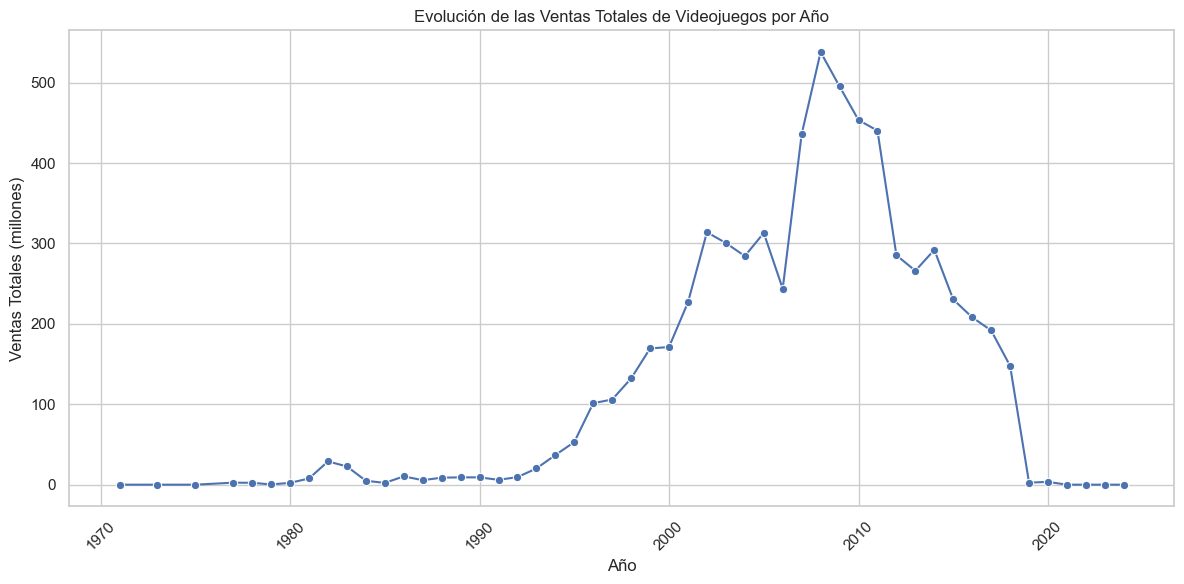

C:\Users\Erick\AppData\Local\Temp\ipykernel_39788\2651675518.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_trimestrales, x='quarter', y='total_sales', palette='muted')


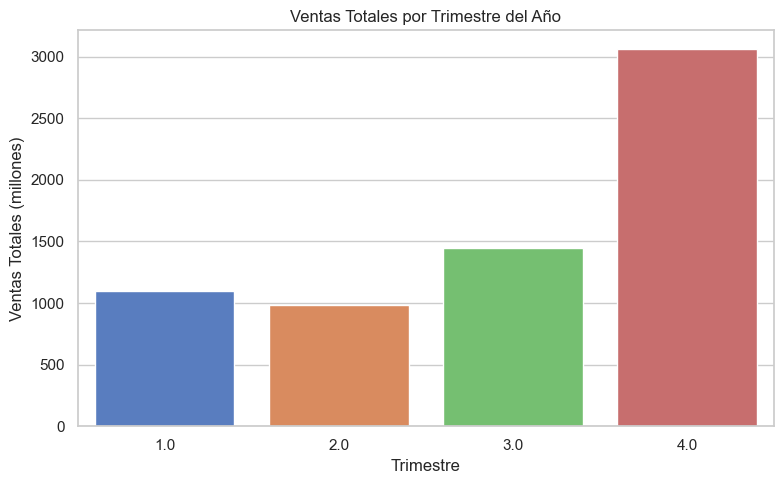

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir 'release_date' a formato datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Crear columnas 'year' y 'quarter'
df['year'] = df['release_date'].dt.year
df['quarter'] = df['release_date'].dt.quarter

# Agrupar ventas totales por año
ventas_anuales = df.groupby('year')['total_sales'].sum().reset_index()

# Agrupar ventas por trimestre (para estacionalidad)
ventas_trimestrales = df.groupby('quarter')['total_sales'].sum().reset_index()

# Configuración de estilo
sns.set(style="whitegrid")

# Gráfica de ventas anuales
plt.figure(figsize=(12, 6))
sns.lineplot(data=ventas_anuales, x='year', y='total_sales', marker='o')
plt.title('Evolución de las Ventas Totales de Videojuegos por Año')
plt.xlabel('Año')
plt.ylabel('Ventas Totales (millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfica de ventas por trimestre
plt.figure(figsize=(8, 5))
sns.barplot(data=ventas_trimestrales, x='quarter', y='total_sales', palette='muted')
plt.title('Ventas Totales por Trimestre del Año')
plt.xlabel('Trimestre')
plt.ylabel('Ventas Totales (millones)')
plt.tight_layout()
plt.show()


# **Tendencias temporales**

**¿Cómo han evolucionado las ventas totales de videojuegos por año?**  
La gráfica muestra un **crecimiento notable en las ventas** durante ciertos años, seguido por **caídas en otros**, lo cual puede estar relacionado con el **ciclo de vida de consolas**, **lanzamientos importantes** o **cambios en la industria**.

**¿Existen estacionalidades (lanzamientos fuertes en Q4, por ejemplo)?**  
**Sí**, como se puede ver en el gráfico, hay **estacionalidades en los lanzamientos de juegos**, especialmente en los **cuatrimestres finales (Q4)** de cada año. Esto puede indicar una **tendencia a concentrar ventas** en los momentos más estratégicos del año, como las **fiestas decembrinas**.
